# Л1 — Підготовка даних

Велика частина роботи в Data Science — збір і підготовка даних. Саме тут виникає багато неочікуваних проблем і пасток.

Ноутбук нижче базово показує, як працювати з даними й готувати їх. Він не охоплює всіх можливих сценаріїв, а приклади в ньому часом сильно спрощені. Проте він дасть розуміння, де шукати помилки і як з ними боротися. Більше туторіалів — у [Kaggle Learn](https://www.kaggle.com/learn), зокрема [Data Cleaning](https://www.kaggle.com/learn/data-cleaning).

Базовий алгоритм підготовки даних може виглядати так (у дужках — кроки цього ноутбука):

- зчитування даних і початкове дослідження (1);
- дослідження структури й особливостей даних, зміна типів (2);
- об'єднання даних з різних джерел (3–4);
- робота з пропущеними й зламаними значеннями: drop, fill тощо (5, 7, 8);
- пошук outliers: drop, clip тощо (6);
- пошук зайвих і бракуючих колонок (9).

І головне: з кожною дією треба бути обережним. Outliers можуть бути реальними даними, які логічно пояснюються і які не можна видаляти. А пропущені значення можуть щось означати й бути корисними. Обидва випадки є в цій роботі.

Далі бувають кроки, специфічні для певних моделей чи алгоритмів:

- scaling: normalization, standardization тощо;
- обробка категорійних колонок: one-hot encoding тощо;
- dimensionality reduction.

Тут вони не розглядаються, частину з них побачите в Л2 і Л3.

Шаблон веде покроково: у кожному кроці — навіщо він і що зробити, у клітинці з `TODO` — ваш код. Опис даних і таблиця недоліків — у `README.md`.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

## 1. Завантаження даних

На цьому етапі важливо впевнитися, що файли завантажено правильно, і подивитися, що взагалі всередині. Можуть допомогти `df.head()`, `df.tail()`, `df.shape` і `df.dtypes`.

Що ви маєте зрозуміти?

- Чи зчиталися дані взагалі?
- Чи правильно розпарсилися рядки, колонки й значення?
- Які типи в колонок?
- Які приблизно значення?
- Скільки рядків і колонок?

In [4]:
df_meters = pd.read_parquet("meters.parquet")
df_registry = pd.read_csv("registry.csv")

print(df_meters.head())
print(df_meters.tail())
print(df_meters.shape)
print(df_meters.dtypes)

print(df_registry.head())
print(df_registry.tail())
print(df_registry.shape)
print(df_registry.dtypes)

   meter_id                  ts  consumption_kwh           record_ts
0  UA100376 2026-01-05 00:00:00           0.9848 2026-01-05 00:04:27
1  UA100376 2026-01-05 01:00:00           0.7786 2026-01-05 01:13:48
2  UA100376 2026-01-05 02:00:00           0.8113 2026-01-05 02:06:58
3  UA100376 2026-01-05 03:00:00           1.8041 2026-01-05 03:07:14
4  UA100376 2026-01-05 04:00:00           1.0292 2026-01-05 04:04:25
        meter_id                  ts  consumption_kwh           record_ts
539891  UA999598 2026-02-01 19:00:00          46.9202 2026-02-01 19:12:54
539892  UA999598 2026-02-01 20:00:00          39.2992 2026-02-01 20:13:34
539893  UA999598 2026-02-01 21:00:00          40.4898 2026-02-01 21:04:08
539894  UA999598 2026-02-01 22:00:00          40.4647 2026-02-01 22:14:39
539895  UA999598 2026-02-01 23:00:00          47.3099 2026-02-01 23:12:38
(539896, 4)
meter_id                   object
ts                 datetime64[us]
consumption_kwh           float64
record_ts          datetime6

## 2. Звірка з описом

Іноді бізнес надає опис ідеальних даних, але реальні дані часто з ним не збігаються. Тому спершу подивіться, чи ваші дані відповідають опису в `README.md`. Може допомогти `df.describe()`.

Перевірте (але поки не виправляйте):

- типи колонок: якщо число прочиталося як текст, частина операцій спрацює неправильно;
- скільки рядків мають `customer_type`, `tariff` чи `electric_heating`, яких немає в описі;
- скільки рядків мають `ts`, `connection_year` чи `years_connected` поза межами з опису;
- скільки різних лічильників у кожному файлі — мають бути по 800.

Можуть допомогти `isin`, `between` і `nunique`.

Недоліки з таблиці в `README.md` перевірятимете далі, кожен у своєму кроці. Межі споживання залежать від типу абонента, а тип є лише в реєстрі, тому їх перевірите після об'єднання, на кроці 6.

In [5]:
print(df_meters.describe())
print(df_registry.describe(include="all"))

                               ts  consumption_kwh                   record_ts
count                      539896    539896.000000                      539896
mean   2026-01-18 23:26:48.163053       652.627347  2026-01-18 23:49:19.290663
min           2026-01-05 00:00:00         0.020300         2026-01-05 00:01:00
25%           2026-01-11 23:00:00         0.419900         2026-01-12 00:03:51
50%           2026-01-18 23:00:00         0.891100  2026-01-19 00:02:29.500000
75%           2026-01-25 23:00:00         2.461800  2026-01-26 00:03:25.250000
max           2026-02-01 23:00:00    253467.200000         2026-02-02 21:51:33
std                           NaN      6185.142864                         NaN
        meter_id customer_type  tariff  electric_heating  connection_year  \
count        800           800     800         800.00000       800.000000   
unique       800             3       2               NaN              NaN   
top     UA100376     household  single               NaN  

## 3. Реєстр: номери й райони (D-E, D-F)

Дані зберігаються в різних системах, тому формат ідентифікатора може не збігатися: `" UA123456"` для pandas — інший номер, ніж `UA123456`. Наївний join призведе до того, що частина даних втратиться. Так само `podil` і `Podil` — різні райони, і будь-який підрахунок по районах буде хибним.

Для D-E і D-F виведіть, скільки рядків реєстру зіпсовано, і виправте їх так, як сказано в таблиці недоліків. Можуть допомогти `str.fullmatch(r"UA\d{6}")`, `isin`, `str.strip()`, `str.lstrip("0")` і `str.capitalize()`.

In [6]:
districts = ["Podil", "Solomianka", "Darnytsia", "Obolon", "Sviatoshyn"]

bad_id = ~df_registry["meter_id"].str.fullmatch(r"UA\d{6}")

print("D-E — зіпсованих meter_id:", bad_id.sum())

df_registry.loc[bad_id, "meter_id"] = (
    df_registry.loc[bad_id, "meter_id"]
    .str.strip()
    .str.lstrip("0")
)

bad_district = ~df_registry["district"].isin(districts)

print("D-F — зіпсованих district:", bad_district.sum())

df_registry.loc[bad_district, "district"] = (
    df_registry.loc[bad_district, "district"]
    .str.strip()
    .str.capitalize()
)

D-E — зіпсованих meter_id: 96
D-F — зіпсованих district: 80


## 4. Об'єднання

Тепер погодинні дані можна об'єднати з реєстром за `meter_id` (join, у pandas — `merge`). pandas не попереджає, коли рядок не знайшов пари, тому якість об'єднання треба перевірити самому.

Об'єднану таблицю назвіть `df`, з нею працюватимете далі. Перевірте й виведіть:

- кількість рядків до і після об'єднання — вона не має змінитися;
- кількість рядків без атрибутів абонента (пропуск у `customer_type`) — має бути 0.

Може допомогти `merge(..., how="left", validate="m:1")`: `validate` ще й перевірить, що кожному лічильнику відповідає один рядок реєстру.

In [7]:
before = len(df_meters)

df = df_meters.merge(
    df_registry,
    on="meter_id",
    how="left",
    validate="m:1"
)

print("Рядків до merge:", before)
print("Рядків після merge:", len(df))
print(
    "Рядків без customer_type:",
    df["customer_type"].isna().sum()
)

Рядків до merge: 539896
Рядків після merge: 539896
Рядків без customer_type: 0


## 5. Повторні відправки (D-C)

Повторна відправка — та сама година того самого лічильника ще раз, іноді з уточненим значенням. Якщо лишити обидва записи, споживання за цю годину подвоїться. Лишаємо найпізніший за `record_ts` запис як найсвіжіший.

Виведіть кількість рядків і кількість різних пар `meter_id` і `ts`, потім зніміть повтори. Можуть допомогти `duplicated(["meter_id", "ts"])`, `sort_values("record_ts")` і `drop_duplicates(["meter_id", "ts"], keep="last")`.

In [8]:
print("Рядків до очищення:", len(df))

print(
    "Різних пар meter_id + ts:",
    len(df[["meter_id", "ts"]].drop_duplicates())
)

print(
    "Повторних рядків:",
    df.duplicated(["meter_id", "ts"]).sum()
)

df = (
    df.sort_values("record_ts")
      .drop_duplicates(
          ["meter_id", "ts"],
          keep="last"
      )
      .copy()
)

print("Рядків після очищення:", len(df))

Рядків до очищення: 539896
Різних пар meter_id + ts: 529402
Повторних рядків: 10494
Рядків після очищення: 529402


## 6. Одиниці виміру (D-D)

Значення у Вт·год схожі на викиди, але це не шум, а помилка одиниць. Якщо їх видалити, зникнуть цілі абоненти.

1. Для кожного лічильника порахуйте відношення його медіани `consumption_kwh` до медіани всіх рядків його `customer_type`. Більше 100 — лічильник звітує у Вт·год.
2. Побудуйте графік медіан лічильників за `customer_type` з логарифмічною віссю, наприклад boxplot.
3. Виведіть кількість лічильників у Вт·год, найбільше відношення серед решти лічильників і найменше серед лічильників у Вт·год (якщо таких немає — лише найбільше відношення серед усіх). Ці числа — доказ у звіті: вони показують, наскільки далеко від порога обидві групи.
4. Поділіть значення цих лічильників на 1000 і виведіть, скільки рядків поза межами споживання з опису, — має бути 0.

Можуть допомогти `DataFrame.boxplot(column=..., by="customer_type")`, `plt.yscale("log")` і `between`. Клітинку з діленням не запускайте двічі: значення поділяться ще раз. Якщо так сталося, перезапустіть ноутбук з початку.

Лічильників у Wh: 64
Найбільше відношення серед решти: 4.21337627427156
Найменше відношення серед Wh: 281.37363506884003


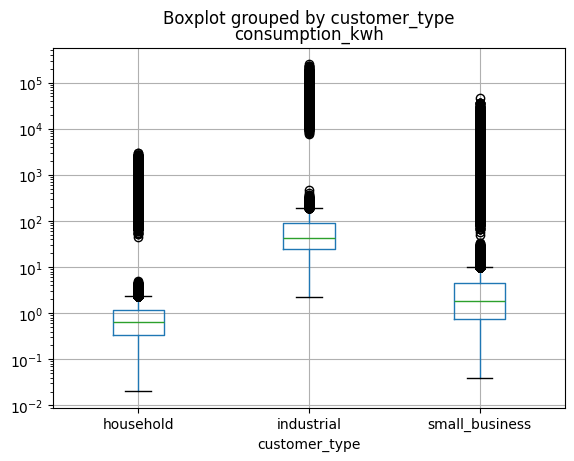

Поза межами після виправлення: 0


In [9]:
meter_median = (
    df.groupby("meter_id")["consumption_kwh"]
      .median()
)

meter_type = (
    df.groupby("meter_id")["customer_type"]
      .first()
)

type_median = (
    df.groupby("customer_type")["consumption_kwh"]
      .median()
)

ratio = (
    meter_median /
    type_median.reindex(meter_type).to_numpy()
)

ratio = pd.Series(
    ratio,
    index=meter_median.index
)

wh_meters = ratio > 100

print(
    "Лічильників у Wh:",
    wh_meters.sum()
)

print(
    "Найбільше відношення серед решти:",
    ratio[~wh_meters].max()
)

print(
    "Найменше відношення серед Wh:",
    ratio[wh_meters].min()
)

df.boxplot(
    column="consumption_kwh",
    by="customer_type"
)

plt.yscale("log")
plt.show()

df.loc[
    df["meter_id"].isin(
        ratio[wh_meters].index
    ),
    "consumption_kwh"
] /= 1000

min_kwh = {
    "household": 0.01,
    "small_business": 0.02,
    "industrial": 1
}

max_kwh = {
    "household": 10,
    "small_business": 60,
    "industrial": 1200
}

lower = df["customer_type"].map(min_kwh)
upper = df["customer_type"].map(max_kwh)

print(
    "Поза межами після виправлення:",
    (~df["consumption_kwh"].between(
        lower,
        upper
    )).sum()
)

## 7. Лічильники, що замовкли (D-A)

Пропуски не заповнюємо: те, що лічильник замовк, уже є інформацією про можливу відмову, а середнє її стерло б. Не видаляємо теж: до відмови лічильник передавав правильні дані.

Для кожного лічильника порахуйте, скільки годин минуло від його останнього `ts` до `2026-02-01 23:00`; більше 48 — замовк. Як на кроці 6, виведіть кількість замовклих, найбільшу тишу серед решти й найменшу серед замовклих (якщо замовклих немає — лише найбільшу тишу серед усіх).

Номери замовклих лічильників збережіть списком `silent`, наприклад `list(....index)`: він знадобиться в регресії.

Можуть допомогти `pd.Timestamp("2026-02-01 23:00")` і `/ pd.Timedelta(hours=1)`.

In [10]:
cutoff = pd.Timestamp("2026-02-01 23:00")

last_ts = (
    df.groupby("meter_id")["ts"]
      .max()
)

silence = (
    cutoff - last_ts
) / pd.Timedelta(hours=1)

silent = list(
    silence[silence > 48].index
)

print("Замовклих:", len(silent))

if silent:
    print(
        "Найбільша тиша серед решти:",
        silence[silence <= 48].max()
    )
    print(
        "Найменша тиша серед замовклих:",
        silence[silence > 48].min()
    )
else:
    print(
        "Найбільша тиша серед усіх:",
        silence.max()
    )

Замовклих: 0
Найбільша тиша серед усіх: 1.0


## 8. Завмерлі лічильники (D-B)

Завмерлі значення виглядають правдоподібно, і ні середнє, ні максимум їх не видають. Помітно лише те, що значення перестали змінюватися. Такі лічильники не видаляємо: частина їхніх годин справна.

Для кожного лічильника порахуйте частку різних значень `consumption_kwh` серед його записів; менше 0.65 — завмер. Побудуйте гістограму цієї частки по лічильниках. Як на кроці 6, виведіть кількість завмерлих, найменшу частку серед решти й найбільшу серед завмерлих (якщо завмерлих немає — лише найменшу частку серед усіх).

Номери завмерлих лічильників збережіть списком `frozen`: він знадобиться в регресії.

Можуть допомогти `nunique()`, `size()` і `plt.hist`.

Завмерлих: 40
Найменша частка серед решти: 0.8303030303030303
Найбільша частка серед завмерлих: 0.5


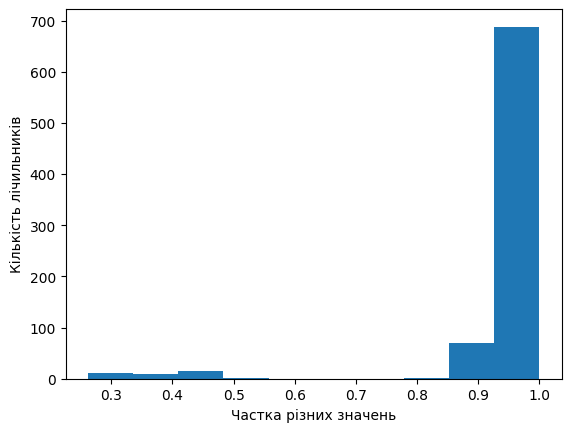

In [ ]:
nunique = (
    df.groupby("meter_id")["consumption_kwh"]
      .nunique()
)

size = (
    df.groupby("meter_id")
      .size()
)

share = nunique / size

frozen = list(
    share[share < 0.65].index
)

print("Завмерлих:", len(frozen))

if frozen:
    print(
        "Найменша частка серед решти:",
        share[share >= 0.65].min()
    )
    
    print(
        "Найбільша частка серед завмерлих:",
        share[share < 0.65].max()
    )

plt.hist(share)
plt.xlabel("Частка різних значень")
plt.ylabel("Кількість лічильників")
plt.show()

## 9. Кореляції

Колонка, що майже копіює іншу, не додає інформації: у кластеризації вона подвоює вагу того самого фактора, а в регресії робить коефіцієнти нестабільними. Технічна колонка `record_ts` після кроку 5 теж не потрібна.

Порахуйте кореляції між числовими колонками об'єднаної таблиці. Пару з кореляцією за модулем понад 0.95 вважайте копією і лиште з неї одну колонку. Приберіть `record_ts`. Підсумкову таблицю назвіть `result`.

Можуть допомогти `select_dtypes("number").corr().abs()` і `drop(columns=...)`.

In [12]:
corr = df.select_dtypes("number").corr().abs()

print(corr)

result = df.drop(
    columns=["years_connected", "record_ts"]
).copy()

                  consumption_kwh  electric_heating  connection_year  \
consumption_kwh          1.000000          0.105365         0.048612   
electric_heating         0.105365          1.000000         0.008168   
connection_year          0.048612          0.008168         1.000000   
years_connected          0.046096          0.008914         0.999073   

                  years_connected  
consumption_kwh          0.046096  
electric_heating         0.008914  
connection_year          0.999073  
years_connected          1.000000  


## 10. Самоперевірка й збереження

Якщо якась перевірка падає, поверніться до відповідного кроку.

In [14]:
districts = ["Podil", "Solomianka", "Darnytsia", "Obolon", "Sviatoshyn"]
min_kwh = {"household": 0.01, "small_business": 0.02, "industrial": 1}
max_kwh = {"household": 10, "small_business": 60, "industrial": 1200}
corr = result.select_dtypes("number").corr().abs()
copies = [(a, b) for a in corr for b in corr if a < b and corr.loc[a, b] > 0.95]

assert not result.duplicated(["meter_id", "ts"]).any(), "лишилися повтори лічильник–година"
assert result["meter_id"].nunique() == 800, "лічильників має бути 800"
assert result["meter_id"].str.fullmatch(r"UA\d{6}").all(), "є номери не у форматі UA і 6 цифр"
assert result["customer_type"].notna().all(), "є рядки без атрибутів абонента"
assert result["district"].isin(districts).all(), "є райони, яких немає в описі"
assert result["consumption_kwh"].between(result["customer_type"].map(min_kwh), result["customer_type"].map(max_kwh)).all(), "є споживання поза межами з опису"
assert not copies, f"лишилися колонки-копії: {copies}"
assert "record_ts" not in result, "технічна колонка record_ts лишилася"

result.to_parquet("cleaned.parquet", index=False)
print("усе гаразд:", result.shape)

усе гаразд: (529402, 8)


## 11. Регресія

Регресію часто використовують, щоб передбачати певні показники. Проте лінійна регресія також показує, як кожен показник впливає на результат. Це і є регресійний аналіз.

Для прикладу подивимося, як на добове споживання домогосподарства впливають електроопалення і двозонний тариф: `y = a + b₁·x₁ + b₂·x₂`.

- `y` — середнє споживання лічильника за добу, кВт·год;
- `x₁` — `electric_heating`, `x₂` — двозонний тариф (обидва 0 або 1);
- `b₁` і `b₂` — на скільки кВт·год на добу більше споживає абонент із цим фактором за однакового іншого;
- `a` — споживання без опалення на звичайному тарифі;
- R² — яку частку розкиду споживання пояснюють обидва фактори, від 0 до 1.

Регресія тут краща за просте порівняння середніх: двозонний тариф здебільшого мають будинки з опаленням, і різниця середніх за тарифом приписала б тарифу ще й споживання на опалення.

Нормалізація не потрібна: обидва фактори мають однаковий масштаб (0 або 1), тож `b₁` і `b₂` можна порівнювати напряму, а `y` лишається в кВт·год на добу, і коефіцієнти легко пояснити. Якби фактори мали різні одиниці, наприклад площу і рік, для порівняння впливу їх спершу стандартизували б.

Лічильники з `silent` і `frozen` не беремо: у `cleaned.parquet` вони лишаються, але їхнє середнє споживання спотворене.

Код майже готовий: допишіть `homes` і запустіть.

In [15]:
homes = result[
    (result["customer_type"] == "household")
    & (~result["meter_id"].isin(silent))
    & (~result["meter_id"].isin(frozen))
]

per_meter = homes.groupby("meter_id").agg(
    kwh_per_day=("consumption_kwh", "mean"),
    electric_heating=("electric_heating", "first"),
    tariff=("tariff", "first"),
)
per_meter["kwh_per_day"] *= 24
per_meter["dual_zone"] = (per_meter["tariff"] == "dual_zone").astype(int)

x, y = per_meter[["electric_heating", "dual_zone"]], per_meter["kwh_per_day"]
model = LinearRegression().fit(x, y)
print("лічильників:", len(per_meter))
print(f"a = {model.intercept_:.2f}, b₁ (опалення) = {model.coef_[0]:.2f}, b₂ (двозонний тариф) = {model.coef_[1]:.2f}, R² = {model.score(x, y):.3f}")

лічильників: 501
a = 11.11, b₁ (опалення) = 16.32, b₂ (двозонний тариф) = 2.12, R² = 0.643
